## 天气数据分析

In [2]:
import pandas as pd
# 加载天气数据
df = pd.read_csv("../data/weather.csv")
df
# 查看基本属性信息
df.shape
df.columns
df.dtypes
# df.info()

# 查看前5行天气情况
df.head()
# 查看后10行天气情况
df.tail(10)

# 加载一列数据
df["date"]  # 没有加中括号，得到的是Series类型对象
df[["date"]]   # 如果加中括号，得到的是dataframe类型对象

# 加载多列数据
# df[["date","temp_max","temp_min"]]




,date
0,2012-01-01
1,2012-01-02
2,2012-01-03
3,2012-01-04
4,2012-01-05
...,...
1456,2015-12-27
1457,2015-12-28
1458,2015-12-29
1459,2015-12-30


In [29]:
# 获取指定位置数据
# 获取行标签为1的数据
df.loc[1]
# 获取行标签分别为1、10、100的数据
df.loc[[1,10,100],["temp_max","temp_min"]]
# 获取行位置为0的数据
df.iloc[0]
# 获取行位置为最后一位的数据
df.iloc[-1]
# 获取行标签为1，列标签为precipitation的数据
df.loc[1,"precipitation"]
# 获取所有行，列标签为precipitation的数据
df.loc[:,"precipitation"]
# 获取所有行，列位置为3，5，最后一位的数据
df.iloc[:,[3,5,-1]]
# 获取前10行，列位置为2、3、4、5的数据
df.iloc[:10,2:6]
# 通过行列标签获取数据



,temp_max,temp_min,wind,weather
0,12.8,5.0,4.7,drizzle
1,10.6,2.8,4.5,rain
2,11.7,7.2,2.3,rain
3,12.2,5.6,4.7,rain
4,8.9,2.8,6.1,rain
5,4.4,2.2,2.2,rain
6,7.2,2.8,2.3,rain
7,10.0,2.8,2.0,sun
8,9.4,5.0,3.4,rain
9,6.1,0.6,3.4,rain


---
## 📘 Claude 讲解：下面这段 groupby + plot 拆解

下一个 code cell 涉及 5 个关键点，先看清楚再往下跑会顺很多。

### 1️⃣ 日期切月：`pd.to_datetime(...).dt.to_period("M").astype(str)`

链式 3 步，从字符串日期变成"月份字符串":

```
"2012-01-15" (字符串)
    │  pd.to_datetime(...)      ← 字符串 → 真日期
    ▼
Timestamp('2012-01-15')
    │  .dt.to_period("M")        ← 取它所在的"月"
    ▼
Period('2012-01', 'M')
    │  .astype(str)              ← 转回字符串
    ▼
"2012-01"
```

**为什么必须先 `to_datetime`**：CSV 读进来 `date` 是 `object`（字符串）类型，字符串没有 `.year`、`.month` 这些属性。只有真日期对象（dtype `datetime64`）才行。

**`.dt` 是什么**：日期 Series 的"访问器"——专门给日期用的方法集合（类比字符串的 `.str`）。

**周期参数表**：

| 参数 | 周期 |
|---|---|
| `"D"` | 天 |
| `"W"` | 周 |
| `"M"` | 月 ← 这里用的 |
| `"Q"` | 季度 |
| `"Y"` | 年 |

**为什么最后 `.astype(str)`**：Period 对象当 groupby key 也行，但**画图时 x 轴标签会更友好**。

### 2️⃣ groupby 三步拆（老师故意展示中间值）

```python
month_group = df.groupby("month")            # ① 分组（懒包装）
stat_column = month_group[["temp_max","temp_min"]]  # ② 选列（仍是懒）
stat_column.mean()                            # ③ 聚合（真正算）
```

**等价于一行**：`df.groupby("month")[["temp_max","temp_min"]].mean()`

老师拆三行**纯教学用**——让你看每一步返回什么类型：

| 步骤 | 返回类型 | 含义 |
|---|---|---|
| `df.groupby("month")` | `DataFrameGroupBy` | "已分组的整张表"（懒包装） |
| `[["temp_max","temp_min"]]` | `DataFrameGroupBy` | 已分组、只看这两列 |
| `.mean()` | `DataFrame` | 真正执行 → 每月一行、两列均值 |

> 你在泰坦尼克号学的"懒包装"概念在这里完全适用——前两步什么都不算，第 3 步才执行。

**中括号细节**：

```python
group["col"]            # 单括号 → Series
group[["col1","col2"]]  # 双括号 → DataFrame
```

和普通 DataFrame 选列规则**完全一样**——单括号 Series、双括号 DataFrame。

### 3️⃣ `nunique()`：数"几种"，不是数"几个"

```python
df.groupby("month")["weather"].nunique()
```

**`nunique` = number of unique** = 每组里有几种**不重复**的值。

对比一下相似聚合：

| 函数 | 含义 | 例：某月 30 天 weather 列 |
|---|---|---|
| `count()` | 非空值的**数量** | 30 |
| `nunique()` | 不重复值的**数量** | 4（rain/sun/fog/drizzle 4 种） |
| `unique()` | 不重复值的**列表** | `['rain','sun','fog','drizzle']` |
| `value_counts()` | 每个值出现几次 | `rain:18, sun:8, fog:3, drizzle:1` |

`nunique` 答的问题是："**这个月天气类型有多丰富？**" 数值越大说明这个月变化越多。

### 4️⃣ `.plot()`：DataFrame 自带的"快速作图开关"

```python
df.groupby("month")[["temp_max", "temp_min"]].mean().plot()
```

这个 `.plot()` 是 **Pandas DataFrame 的方法**，不是 matplotlib——但**底层调的是 matplotlib**。它把这 4 行省成 1 行：

```python
# .plot() 等价于背后做了这些事：
import matplotlib.pyplot as plt
result = df.groupby("month")[["temp_max", "temp_min"]].mean()
plt.plot(result.index, result["temp_max"], label="temp_max")
plt.plot(result.index, result["temp_min"], label="temp_min")
plt.legend()
plt.show()
```

**默认规则**：

| Pandas 怎么画 | 用什么 |
|---|---|
| x 轴 | DataFrame 的 **index**（这里是 `month`） |
| 每条线 | 每一列（`temp_max` 和 `temp_min` 两条线）|
| 线名 | 列名（自动当 legend） |

**想换图表类型**：

```python
.plot(kind='line')   # 折线（默认）
.plot(kind='bar')    # 柱状
.plot(kind='hist')   # 直方图
.plot(kind='box')    # 箱线
.plot(kind='scatter', x='temp_max', y='temp_min')  # 散点
```

**速记**：快速看一眼 → `df.plot()`；要美观/复杂 → seaborn + matplotlib。

### 5️⃣ 这张图会画出什么

横轴：48 个月（2012-01 到 2015-12）
纵轴：温度（°C）
两条线：每月平均最高 + 平均最低

**预期 4 个完美的"驼峰"**——每年夏高冬低、四季分明、规律重复。

```
30│   ╱╲    ╱╲    ╱╲    ╱╲      ← temp_max
 │  ╱  ╲  ╱  ╲  ╱  ╲  ╱  ╲
10│ ╱   ╲╱   ╲╱   ╲╱   ╲╱
 │╱╲ ╱╲ ╱╲ ╱╲                    ← temp_min
 0│  ╲╱  ╲╱  ╲╱
 ────────────────────────────▶
   2012 2013 2014 2015
```

> 数据是**美国西雅图**的天气（Pandas 教程经典数据集）——四季分明、降雨偏多。

### 综合速记

| 技巧 | 用法 | 何时用 |
|---|---|---|
| 字符串日期 → 真日期 | `pd.to_datetime(df["col"])` | CSV 读进来日期都得这一步 |
| 日期 → 周期 | `.dt.to_period("M")` | 按月/季/年分组统计 |
| 一组聚合多列 | `groupby(...)[["a","b"]].mean()` | 双层括号选多列 |
| 数"种类" | `.nunique()` | 不是数"个数"，是数"几种" |
| 快速画图 | `df.plot()` | DataFrame 自带，省 matplotlib 样板 |

---


---
## 📘 Claude 讲解（深化版）：`groupby` 是一个「作用域开关」

> 上面那个讲解 cell 是机制层。下面这个是**直觉层** —— 看懂这一个观念后，所有 `groupby...聚合` 类的链你都能秒读。

### 你之前的卡点

看到 `df.groupby("month")[["temp_max","temp_min"]].mean()`，**第一直觉读成**：

> "求 temp_max 和 temp_min 的平均"

然后觉得"这没意义啊"，反推才到"哦，是每月每列的平均"。

**问题**：靠业务反推累，下次见到陌生的 `groupby` 链又得反推一遍。**根因是没建立"语法层面的读法规则"**。

### 一句话规则（看 Pandas 代码的钥匙）

> **`groupby` 是一个"作用域开关"——一旦挂上它，后面的所有操作都自动变成"每组各做一次"。**

```
df.mean()                            df.groupby("month").mean()
   ↑                                    ↑
没 groupby：                         有 groupby：
mean 面对整张表 → 1 个结果           mean 面对每个组 → N 个结果
```

`mean` 这个函数没变。变的是**它面对的数据是什么**——这才是 groupby 的作用。

### 读链子的正确方法

把每个 `.xxx` 当作**独立动作**，每步问一句："**现在我面对什么数据？**"

以 `df.groupby("month")[["temp_max","temp_min"]].mean()` 为例：

| 链上的位置 | 现在面对什么 |
|---|---|
| `df` | 一张 1461 行的大表 |
| `df.groupby("month")` | **48 张小桌子**（每月一桌）|
| `...[["temp_max","temp_min"]]` | 每张小桌子，只看 2 列 |
| `...mean()` | **每张小桌子各算一次平均** |

**关键转变在第 2 步**：从"一张大表"变成"48 张小桌子"。后面所有操作**自动作用于每张小桌子**——这是 Pandas 帮你做的隐式分发，不用你写循环。

### 错读法 vs 对读法

**❌ 错读法（一句话读完）**：
> "按月分组、选两列、求平均"

→ 模糊。"求平均"作用于啥不清楚，只能脑补。

**✅ 对读法（逐步读，问"作用于什么"）**：
> "先变成 48 张小桌子（按月）→ 每桌只看两列 → 每桌各算一次平均"

→ 清晰。"作用对象"在每一步都明确。

### iOS / Swift 类比锁直觉

```swift
// 没分组
let avg = students.map(\.score).average           // → 1 个数

// 分组
let byClass = Dictionary(grouping: students, by: \.className)
let avgPerClass = byClass.mapValues { $0.map(\.score).average }
//                       ↑
//                  自动对每组各做一遍
// → 每个班一个数
```

**`Dictionary(grouping:)` + `mapValues` 就等同于 Pandas 的 `groupby` + 聚合**。`mapValues` 这个词比"groupby"更直白——它明确说"把这个操作对每个 value 做一遍"。Pandas 的 `groupby` 同样是这个机制，只是名字没那么提示。

### 这条规则对一切聚合函数都适用

不只是 `mean`——你换成下面任何一个，规则都不变：

```python
df.groupby("month").mean()    # 每月各算一次平均
df.groupby("month").max()     # 每月各取一次最大
df.groupby("month").std()     # 每月各算一次标准差
df.groupby("month").count()   # 每月各数一次非空数
df.groupby("month").size()    # 每月各数一次总行数
```

**`groupby` 一挂上，所有聚合都自动每组化**。这是看懂 Pandas 70% 复杂操作的钥匙。

---

## 拓展：多列分组 `groupby(["month", "weather"])`

我刚问过你：`df.groupby(["month","weather"])["temp_max"].mean()` 返回多少行？你没把握——这一节解释清楚。

### 单列 vs 多列分组的差异

```python
df.groupby("month")              # 按 month 单列分 → 48 组
df.groupby(["month","weather"])  # 按 (month, weather) 双列分 → 100-200 组
```

**多列分组的规则**：

> **按 N 列分组 = 按这 N 列值的"所有不重复组合"分组**。每个出现过的组合就是一组。

### 想象成一张二维表格

把数据展开成"月份 × 天气类型"的网格。**单元格里的数字 = 那个月这种天气有几天**：

```
              rain   sun   fog   snow   drizzle
2012-01        18     8     3     1       1      ← 5 种都出现 → 5 个组
2012-02        15    10     2     2       —      ← drizzle 这月没出现 → 4 个组
2012-03        20     7     2     —       2      ← snow 这月没出现 → 4 个组
...
2015-12        16     8     3     1       2      ← 5 种都出现 → 5 个组
```

> ⚠️ **关键认知**：`—` **不是"有这组合但值是 0"**，而是**"这组合根本不存在"**。
>
> 比如 `(2012-02, drizzle)`：如果 2 月的 29 天里**没有任何一天**的 weather 是 drizzle，那么 groupby **不会**为这个组合建组——它在结果里**压根不存在**，不是"存在但是 0"。

**每个出现过的组合 = 一组 = 结果里一行**。

### 一条关键规则：groupby 不会"补齐"

> **`groupby` 是从数据里"发现"组，不是凭空"枚举"所有可能。**
>
> 出现过的组合才有组，**没出现的视为不存在**。

| 数学上可能的组合 | 实际建组的组合 |
|---|---|
| 48 个月 × 5 种天气 = **240 个** | 大约 **150 个**（每月平均 3-4 种天气出现） |

`groupby(["month","weather"])` 后**不会**有 240 行结果——只有大约 150 行，对应 150 个实际出现的 `(月, 天气)` 组合。

### 如果你想"补齐"成 240 行（不存在的填 0）

需要在 groupby 之后用 `unstack(fill_value=0)` 或 `reindex`：

```python
df.groupby(["month", "weather"]).size().unstack(fill_value=0)
#                                          ↑
#                             把不存在的组合在矩阵里填 0
```

**默认行为是"只算存在的组合"**——这是后话，看到再用。

每组在结果里是**一行**，行的"标签"是一个**元组 `(月份, 天气)`**：

```
                       temp_max
month     weather
2012-01   rain          12.5    ← 这一月这一天气的平均
2012-01   sun            8.2
2012-01   fog            6.1
2012-01   snow           1.8
2012-01   drizzle        9.0
2012-02   rain          14.3
2012-02   sun           11.0
...
```

### 为什么这样有用

按"月 × 天气"分组比按"月"分组**信息更细**。能回答这种问题：

- "2012 年 1 月，下雨天的平均温度 vs 晴天的平均温度" ← 单列分组答不了
- "西雅图哪个月最适合户外活动？" → 找"晴天均温高 + 晴天天数多"的组合

### 用规则反过来检验

按"作用域开关"规则读：

| 链上的位置 | 现在面对什么 |
|---|---|
| `df` | 1461 行大表 |
| `df.groupby(["month","weather"])` | **100-200 张小桌子**（每个 (月, 天气) 组合一桌） |
| `...["temp_max"]` | 每张小桌子，只看 temp_max 这一列 |
| `...mean()` | 每张小桌子各算一次平均 |

输出：**100-200 行结果**，index 是 `(month, weather)` 的二级索引。

### 一句话钉死多列分组

> **`groupby([列A, 列B])` 把表按 A、B 的"所有不重复组合"切成小桌子**。多一个分组列 = 切得更细。

---

**现在试着默念下面这条链的输出几行**（不看答案）：

```python
df.groupby(["month", "weather"])[["temp_max", "temp_min"]].mean()
```

<details>
<summary>展开看</summary>

- **行数**：和 `groupby(["month","weather"])["temp_max"].mean()` 一样——100-200 行（分组方式没变）
- **列数**：2 列（`temp_max` 和 `temp_min`，因为选了两列）
- **每个格子**：那个 `(月, 天气)` 组合的 `temp_max` 平均或 `temp_min` 平均

**多列分组 + 多列聚合 = 二维细分网格的统计**。看起来吓人，本质只是规则的两条扩展叠加在一起。

</details>
---


<Axes: xlabel='month'>

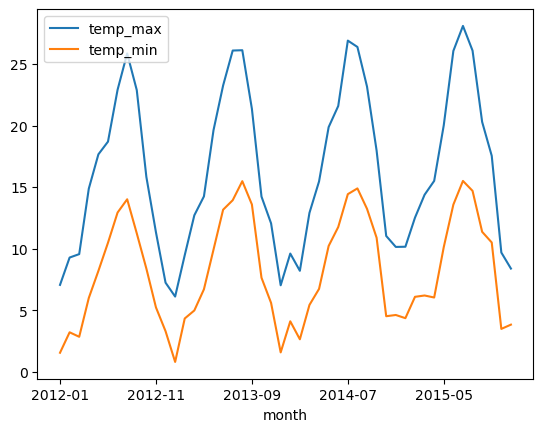

In [51]:
# 分组聚合
# mysql :  select 分组字段,聚合函数 from 表 group by 分组字段
# df.groupby("分组字段")["要聚合的字段"].聚合函数()
# df.groupby(["分组字段", "分组字段2", ...])[["要聚合的字段", "要聚合的字段2", ...]].聚合函数()

# （1）将数据按月分组，并统计最大温度和最小温度的平均值
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)

month_group = df.groupby("month")
stat_column = month_group[["temp_max","temp_min"]]
stat_column.mean()

# df.groupby("month")[["temp_max","temp_min"]].mean()


# 统计每个月不同天气状况的数量
df.groupby("month")["weather"].nunique()

df.groupby("month")[["temp_max", "temp_min"]].mean().plot()



---
## 📘 Claude 讲解：`.describe(include=np.float64).T` 三件套

下一行代码这么短，却塞了 3 个独立知识点。

```python
df[["temp_max","temp_min"]].describe(include=np.float64).T
```

| 段 | 教什么 |
|---|---|
| `.describe()` | "看数值列分布"的瑞士军刀 |
| `include=np.float64` | 按 dtype 过滤要统计哪些列 |
| `.T` | 转置——把行列互换，让结果更可读 |

---

### 知识点 1：`.describe()` —— 8 个统计一把出

输出**固定 8 个统计量**：

| 统计 | 含义 |
|---|---|
| `count` | 非空值数量 |
| `mean` | 平均值 |
| `std` | 标准差（"波动有多大"）|
| `min` | 最小值 |
| `25%` | 25 分位数（下四分位）|
| `50%` | 中位数 |
| `75%` | 上四分位 |
| `max` | 最大值 |

**`describe()` 是拿到数据集的第一动作**。比单独写 `mean() / std() / min()` 快得多。

### 知识点 2：`include=` —— 按 dtype 过滤列

`describe()` 默认行为：

| 数据情况 | 默认 describe |
|---|---|
| 全数值列 | 输出数值统计 |
| 全字符串列 | 输出 `unique / top / freq` |
| 混合列 | **只算数值列**，字符串列被忽略 |

`include=` 参数明确控制要哪些类型：

```python
df.describe()                       # 默认：只看数值列
df.describe(include='all')          # 数值 + 字符串全要
df.describe(include=[np.number])    # 所有数值类型（int + float）
df.describe(include=np.float64)     # 只要 float64 ← 这里用的
df.describe(include='object')       # 只要字符串列
df.describe(exclude=np.number)      # 排除数值列
```

**这里为什么用 `include=np.float64`**：老师演示"精确控制只看 float64 列"。但因为已经选了 `[["temp_max","temp_min"]]`（本来就都是 float64），加不加结果一样——**纯粹借机教参数**。

实战用到的场景：df 有 20+ 列混合 int/float/string，你只关心 float 列时，一键过滤。

### 知识点 3：`.T` —— 转置（行列互换）

`.T` 等同于 `.transpose()`。

#### 不转置（默认）：行=统计、列=字段

```
        temp_max  temp_min
count    1461     1461
mean    16.44     8.23
std      7.35     5.02
min     -1.6     -7.1
...
```

#### 转置后：行=字段、列=统计

```
           count   mean    std  min  ...  max
temp_max  1461   16.44   7.35  -1.6  ...  35.6
temp_min  1461    8.23   5.02  -7.1  ...  18.3
```

**经验法则**：

- **字段少（2-3 个）、统计多** → 不转置（默认）
- **字段多（10+ 个）、看分布** → 转置（`.T`）

字段多时不转置 = 超宽横向表（眼睛左右扫）；转置 = 窄长纵向表（眼睛上下扫）。

---

### 整段代码的意图

```python
df[["temp_max","temp_min"]]            # ① 选要看的列
    .describe(include=np.float64)       # ② 一次性出 8 个统计 + dtype 过滤
    .T                                   # ③ 转置成"字段竖、统计横"的可读形式
```

**老师等于教了 3 件事**：describe 是数据分析"第一动作" + include 按类型过滤 + .T 排版技巧。

---

### 实战常用姿势（背下来）

```python
# 1. 标准用法：拿到数据先看一眼
df.describe()

# 2. 字段多时转置阅读
df.describe(include='all').T

# 3. 看字符串列的分类信息（非常常用）
df.describe(include='object').T
#         count  unique  top   freq
# weather  1461       5  rain  641
# → 1461 行、5 种天气、最常见是 rain（641 天）

# 4. 找数据异常
df.describe().T
# 看 max 是否异常大 / min 是否异常小
# 看 mean 和 50% 差距大不大（差距大说明分布偏）
# 看 count 是否和总行数一致（不一致说明有 NaN）
```

**`df.describe()` 大概率是你以后每个数据分析项目的第一行代码**。


In [58]:
import numpy as np
df[["temp_max","temp_min"]].describe(include=np.float64).T


,count,mean,std,min,25%,50%,75%,max
temp_max,1461.0,16.439083,7.349758,-1.6,10.6,15.6,22.2,35.6
temp_min,1461.0,8.234771,5.023004,-7.1,4.4,8.3,12.2,18.3


---
## 📘 Claude 讲解：nlargest / nsmallest + "每组最大"三解法

下一段 cell 教 3 个独立技巧：

| 题号 | 教什么 |
|---|---|
| （1） | `nlargest` —— 取最大的 N 行（整行返回）|
| （2） | 链式调用 `nlargest().nsmallest()` |
| （3） | "找每组最大"的两种解法（**含 bug**，先看说明） |

---

### 题（1）（2）：`nlargest` / `nsmallest` —— 取最大 / 最小的 N 行

```python
df.nlargest(30, "temp_max")    # 按 temp_max 排序，返回最大的 30 整行
df.nsmallest(5, "temp_min")    # 按 temp_min 排序，返回最小的 5 整行
```

**对比 `sort_values + head`**：

```python
# 等价写法
df.sort_values("temp_max", ascending=False).head(30)
# 等价于
df.nlargest(30, "temp_max")
```

**用 `nlargest` 的好处**：意图明确，写法短。

#### 题（2）：链式调用展示

```python
df.nlargest(30, "temp_max").nsmallest(5, "temp_min")
```

意思是：**先**取 30 天最高温最大的、**再**从这 30 天里取最低温最小的 5 天。

读法：从左往右 = 数据流向。前一步的结果交给后一步处理。

---

### 🚨 题（3）有个 bug：`year` 列没创建

代码长这样：

```python
# （3）找出每年的最高温度
# df["year"] = pd.to_datetime(df["date"]).dt.year   ← 注释掉了！
# df.groupby("year")["temp_max"].max()

year_sort = df.sort_values(by=["year","temp_max"], ascending=[True,False])
year_sort.drop_duplicates(subset=["year"])
```

直接跑会报 **`KeyError: 'year'`** ——因为创建 `year` 列那一行被注释了。

#### 直接修复

**取消第一行的注释**：

```python
df["year"] = pd.to_datetime(df["date"]).dt.year    # ← 去掉前面的 #

# df.groupby("year")["temp_max"].max()             # 这行保留注释，是另一种解法

year_sort = df.sort_values(by=["year","temp_max"], ascending=[True,False])
year_sort.drop_duplicates(subset=["year"])
```

#### 为什么老师的 ipynb 输出里看得到 year 列？

经典 **Jupyter 隐式状态陷阱**：

> Jupyter 的 cell 输出会保存到文件，但**代码改了输出不会自动失效**。老师在录课时先去掉注释跑了一次，留下了输出；然后又加回注释保存了文件——结果"代码 ≠ 输出"。

**遇到这种情况的反射动作**：

1. 看到代码和输出对不上 → 怀疑这种情况
2. 重启 kernel（菜单 → Kernel → Restart）→ 全部从头跑一遍
3. 看哪一步真出错

---

### 题（3）真正在教的：sort + drop_duplicates 实现"每组最大"

这段代码用了一种**"非典型"思路**找每年最高温：

#### Step 1：双层排序

```python
year_sort = df.sort_values(by=["year","temp_max"], ascending=[True,False])
```

`by=[...]` + `ascending=[...]` 列表对应，**双层排序**：

- 先按 `year` **升序**（2012 → 2015）
- 同一年内，按 `temp_max` **降序**（每年最热的天排在该年最上面）

排完表：

```
date         year  temp_max
2012-08-16   2012   34.4    ← 2012 年最热（排第一）
2012-08-15   2012   33.9
...
2013-06-30   2013   33.9    ← 2013 年最热
...
2014-08-11   2014   35.6    ← 2014 年最热
...
```

#### Step 2：按 year 去重

```python
year_sort.drop_duplicates(subset=["year"])
```

`subset=["year"]` 表示**只看 year 列重不重复**——同 year 多行只保留**第一行**。

由于 Step 1 让每年的第一行就是该年最热天 → 结果就是 4 年的最高温记录（完整行）。

---

### "每组最大" 3 种解法对比（值得背下来）

| 解法 | 写法 | 返回内容 | 推荐度 |
|---|---|---|---|
| ① groupby + max | `df.groupby("year")["temp_max"].max()` | 只有数值 | 信息够时用 |
| ② sort + drop_duplicates | `df.sort_values([k1,k2],[T,F]).drop_duplicates([k1])` | **整行**信息 | 老师在教的 |
| ③ groupby + idxmax | `df.loc[df.groupby("year")["temp_max"].idxmax()]` | **整行**信息 | **最优雅**，强烈推荐 |

**解法 ③ 的语义最清晰**：

```python
df.loc[df.groupby("year")["temp_max"].idxmax()]
#       │              │            │
#       │              │            └─ 每组里"最大那一行的 index"
#       │              └─ 按 year 分组、看 temp_max
#       └─ 用这些 index 从原表取整行
```

实战代码里这种写法最常见，**推荐你以后默认这么写**。

老师教解法 ② 不是因为它最好，而是借机教两个独立技能：
- `sort_values` 的双层排序（`ascending=[T,F]` 列表对应）
- `drop_duplicates` 的 `subset` 参数

---

### 修复后的代码（你照着改）

```python
# （1）找到最高温度最大的30天
df.nlargest(30, "temp_max")

# （2）从最高温度最大的30天中找出最低温度最小的5天
df.nlargest(30, "temp_max").nsmallest(5, "temp_min")

# （3）找出每年的最高温度
df["year"] = pd.to_datetime(df["date"]).dt.year      # 必须先创建 year 列

# 解法 ①（简单版）：只得到数值
# df.groupby("year")["temp_max"].max()

# 解法 ②（老师在教）：sort + drop_duplicates 得到整行
year_sort = df.sort_values(by=["year","temp_max"], ascending=[True,False])
year_sort.drop_duplicates(subset=["year"])

# 解法 ③（最推荐）：groupby + idxmax
# df.loc[df.groupby("year")["temp_max"].idxmax()]
```

---


In [10]:
# （1）找到最高温度最大的30天
df.nlargest(30, "temp_max")

# （2）从最高温度最大的30天中找出最低温度最小的5天
df.nlargest(30, "temp_max").nsmallest(5, "temp_min")

# （3）找出每年的最高温度
df["year"] = pd.to_datetime(df["date"]).dt.year      # 必须先创建 year 列

# 解法 ①（简单版）：只得到数值
# df.groupby("year")["temp_max"].max()

# 解法 ②（老师在教）：sort + drop_duplicates 得到整行
year_sort = df.sort_values(by=["year","temp_max"], ascending=[True,False])
year_sort.drop_duplicates(subset=["year"])

# 解法 ③（最推荐）：groupby + idxmax
df.loc[df.groupby("year")["temp_max"].idxmax()]

,date,precipitation,temp_max,temp_min,wind,weather,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015
